# What is NLP?

**Natural Language Processing (NLP)** is a field of artificial intelligence that focuses on enabling computers to understand, interpret, and generate human language. It's the bridge that allows machines to process and make sense of the vast amount of text and speech data that humans produce.

The primary goal of NLP is to build systems that can perform tasks involving language, such as:

*   **Understanding:** Extracting meaning, identifying entities, analyzing sentiment, and understanding the structure of language.
*   **Interpretation:** Handling ambiguity, recognizing context, and inferring intent.
*   **Generation:** Creating human-like text or speech.

NLP draws upon various disciplines, including computer science, linguistics, and machine learning. It's the technology behind many everyday applications, such as:

*   **Search engines:** Understanding your search queries.
*   **Voice assistants:** Processing and responding to spoken commands.
*   **Machine translation:** Translating text or speech between languages.
*   **Sentiment analysis:** Determining the emotional tone of text (e.g., positive, negative, neutral).
*   **Chatbots and conversational AI:** Enabling natural language interactions with computers.
*   **Spam detection:** Identifying unwanted emails based on their content.
*   **Text summarization:** Creating concise summaries of longer texts.

In essence, NLP aims to make computers as adept at understanding and using language as humans are, opening up possibilities for more intuitive and powerful interactions between people and machines.

Let’s build you a crisp, end-to-end map of NLP, with runnable Python at each stage. you’ll see: classic (“feature + ML”) and modern (“transformers”) paths, plus tips for production.


# The pipeline (bird’s-eye)

Ingest → Normalize/clean → Tokenize → Stopwords/ Stemming/Lemmatization(optional) → Linguistic analysis (POS, NER, dependencies) → Features/embeddings → Model → Evaluate → Deploy & Monitor.

---


## **Big picture flow of how text becomes insights**

**End-to-end NLP pipeline** —  basically the *assembly line* that raw human text goes through before it becomes usable for a model and then for production.


Let’s break it down step by step:

---

### **1) Ingest**

* Collect text data from sources: files, databases, APIs, logs, chat transcripts, websites, etc.
* Example: scraping tweets, collecting customer reviews, ingesting PDFs.

---

### **2) Normalize / Clean**

* Standardize and simplify text so models can understand it.
* Remove noise (HTML tags, emojis if not needed, duplicate spaces).
* Lowercasing (for some tasks).
* Replace URLs/emails/numbers with placeholders.

Example:
`"Email me at A.B@example.com after reading https://example.org: it costs $14.99!"`
becomes → `"email me at <EMAIL> after reading <URL> it costs <NUM>"`

---

### **3) Tokenize**

* Break text into **tokens** = words, subwords, or characters.
* Tokens are the basic units that models “see”.
* Traditional ML: word tokens.
* Modern transformers: subwords (e.g., WordPiece, BPE).

Example:
Sentence: `"I'm loving NLP"`
Tokens: `["I", "'m", "loving", "NLP"]`

---

### **4) Stopwords, Stemming, Lemmatization (optional)**

* **Stopwords**: remove very frequent words (e.g., "the", "is") that don’t add meaning (for some tasks).
* **Stemming**: chop suffixes → `"running" → "run"`.
* **Lemmatization**: use dictionary rules → `"better" → "good"`, `"mice" → "mouse"`.

---

### **5) Linguistic Analysis (POS, NER, Dependencies)**

* **POS tagging**: parts of speech (noun, verb, adjective) - `spaCy's t.pos_`.
* **NER**: named entities recognition(people, places, money, dates) `spaCy's doc.ents`.
* **Dependency parsing**: grammatical structure (who did what to whom) `spaCy's t.dep_ and t.head.text`
.

Example:
Sentence: `"Apple bought Beats for $3B in California."`

* **POS**: Apple ->  `PROPN` (Proper Noun), Beats -> `PROPN` (Proper Noun).

* **NER**: `Apple → ORG`, `Beats → ORG`, `$3B → MONEY`, `California → GPE`.

* **Dependency**: Apple -> `nsubj` (Nominal subject) - `Apple` is the subject performing the action (bought).
 Bought -> `ROOT` - This is the main verb of the sentence.

---

### **6) Features / Embeddings**

This stage is about converting text into numerical representations that machine learning models can understand. There are two main categories of techniques for this:

#### **Count-based Representations**

These methods focus on the frequency of words or sequences of words. They create **sparse vectors** (vectors with many zero values) where each dimension often corresponds to a term in a vocabulary.

*   **Bag-of-Words (BoW):** Represents text as a bag of its words, disregarding grammar and even word order, but keeping multiplicity. The value in the vector is typically the count of how many times a word appears.
*   **N-grams:** Similar to BoW, but considers sequences of N words (e.g., bigrams are sequences of two words like "great camera").
*   **TF-IDF (Term Frequency-Inverse Document Frequency):** Weights word counts by how often they appear in the current document (TF) versus how often they appear across all documents in the corpus (IDF). This helps highlight words that are important to a document but not overly common everywhere.

➡️ While these are numerical vectors, they **do not inherently capture the meaning or semantic relationships** between words. They are based purely on statistical frequency.

#### **Embedding-based Representations**

These methods aim to map words or pieces of text into **dense vectors** (vectors with mostly non-zero values) in a continuous, lower-dimensional space. The key idea is that words with similar meanings will have similar vector representations (be close to each other in this space).

*   **One-hot Encoding:** A very basic, sparse, high-dimensional representation where each word is a vector with a single '1'. **Does NOT capture semantic meaning.** This is a precursor concept to true embeddings.
*   **Static Word Embeddings (Word2Vec, GloVe, FastText):** Learned dense vectors where each unique word is mapped to a fixed vector, regardless of its context. **Capture semantic relationships.** The famous example `"king" - "man" + "woman" ≈ "queen"` illustrates how these vectors can capture relationships.
*   **Contextual Embeddings (BERT, GPT, etc.):** More advanced dense embeddings where the vector representation for a word changes depending on its context in a sentence. **Crucial for handling polysemy and capture nuanced meaning.**

➡️ Embedding-based methods **do capture semantic meaning and relationships**, as they are learned from large amounts of text data. The dimensionality is typically much lower than count-based methods or one-hot encoding.

In summary, this step is crucial for transforming unstructured text into a structured numerical format that can be fed into various machine learning models for tasks like classification, clustering, or sequence generation.
---

### **7) Model**

Apply ML/DL models for the task:

* Classic ML: Logistic Regression, SVM, Naive Bayes (with TF-IDF).
* Deep learning: RNN, LSTM, CNN for text.
* Transformers: BERT, GPT, T5 (state-of-the-art for most tasks).

---

### **8) Evaluate**

Measure performance on test/validation data.

* Classification → accuracy, precision, recall, F1, ROC AUC.
* Summarization/translation → BLEU, ROUGE.
* Retrieval → Recall\@k, nDCG.
* NER → token-level F1.

---

### **9) Deploy & Monitor**

* Deploy the model as an API, chatbot, search engine, etc.
* Monitor latency, accuracy drift, input distribution, cost.
* Retrain if data drifts (language changes, new slang, new domains).

---


In [ ]:
# Quick Setup
!pip install -U spacy scikit-learn nltk gensim transformers torch sentencepiece

!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 40.1 MB/s eta 0

^C



# 1) Normalization & cleaning

common steps: unicode normalization, lowercasing (task-dependent), punctuation/number handling, URL/usernames, contractions.

---

In [ ]:
import re, unicodedata

def normalize(text: str) -> str:
    # unicode normalize
    text = unicodedata.normalize("NFKC", text)
    # squash whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_for_bow(text: str) -> str:
    text = normalize(text)
    text = text.lower()          # avoid for tasks where case matters (e.g., NER)
    # replace urls/emails/numbers with placeholders
    text = re.sub(r"http\S+|www\.\S+", " <URL> ", text)
    text = re.sub(r"\S+@\S+", " <EMAIL> ", text)
    text = re.sub(r"\d+(\.\d+)?", " <NUM> ", text)
    # keep letters/apostrophes
    text = re.sub(r"[^a-z'<>\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

sample = "Email me at A.B@example.com after reading https://example.org: it costs $14.99!"
print(clean_for_bow(sample))

email me at < > after reading < > it costs < >


# 2) Tokenization (sentence/word/subword)

* word/sentence tokenization → good for classic ML and rule-based work.

In [ ]:
# simple word tokens (regex)
import re
def word_tokens(text): return re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?|<URL>|<EMAIL>|<NUM>", text)

# sentence split (simple rule; for robust use spaCy)
def sent_split(text): return re.split(r"(?<=[.!?])\s+", text)

print(word_tokens("I'm loving NLP—it's fun! <NUM>"))
print(sent_split("NLP is fun. Transformers rock! Right?"))

["I'm", 'loving', 'NLP', "it's", 'fun', '<NUM>']
['NLP is fun.', 'Transformers rock!', 'Right?']


* spaCy: linguistic tokens, POS, NER, dependencies:

  For each token t, this creates a tuple containing:
  * `t.text`: The original text of the token.
  * `t.lemma_`: The base form of the word (lemmatization).
  * `t.pos_`: The part-of-speech tag of the token (e.g., NOUN, VERB, ADJ).
  * `t.dep_`: The dependency relation of the token to its head.
  * `t.head.text`: The original text of the token's syntactic head (the word it is grammatically related to).

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")
doc = nlp("Apple is paying $3B to acquire Beats from Dr. Dre in California.")
[(t.text, t.lemma_, t.pos_, t.dep_, t.head.text) for t in doc[:]]

[('Apple', 'Apple', 'PROPN', 'nsubj', 'paying'),
 ('is', 'be', 'AUX', 'aux', 'paying'),
 ('paying', 'pay', 'VERB', 'ROOT', 'paying'),
 ('$', '$', 'SYM', 'nmod', '3B'),
 ('3B', '3b', 'NOUN', 'dobj', 'paying'),
 ('to', 'to', 'PART', 'aux', 'acquire'),
 ('acquire', 'acquire', 'VERB', 'acl', '3B'),
 ('Beats', 'Beats', 'PROPN', 'dobj', 'acquire'),
 ('from', 'from', 'ADP', 'prep', 'acquire'),
 ('Dr.', 'Dr.', 'PROPN', 'compound', 'Dre'),
 ('Dre', 'Dre', 'PROPN', 'pobj', 'from'),
 ('in', 'in', 'ADP', 'prep', 'acquire'),
 ('California', 'California', 'PROPN', 'pobj', 'in'),
 ('.', '.', 'PUNCT', 'punct', 'paying')]

In [ ]:
[(ent.text, ent.label_) for ent in doc.ents]

[('Apple', 'ORG'),
 ('3B', 'MONEY'),
 ('Beats', 'NORP'),
 ('Dre', 'PERSON'),
 ('California', 'GPE')]

In [ ]:
[str(sent) for sent in doc.sents]

['Apple is paying $3B to acquire Beats from Dr. Dre in California.']

* Subword Tokenization (BPE/WordPiece) → required for transformers (handles OOV robustly).

**Subword Tokenization** is a method of breaking down text into units that are smaller than words but larger than characters. Instead of treating each word as a unique token, it learns a vocabulary of common subword units from the training data.

  Here's why it's important and why it's often required for transformers:

  1.  **Handles Out-of-Vocabulary (OOV) words robustly:** This is a major advantage. Traditional word-based tokenization struggles with words it hasn't seen before (OOV words). Subword tokenization can break down an unknown word into known subword units. For example, the word "unpredictable" might be broken into "un", "predict", and "able". Even if "unpredictable" wasn't in the vocabulary, the model can still understand it based on the known subwords. This is crucial for handling variations in language, typos, and new words.

  2.  **Manages Vocabulary Size:** While characters are too fine-grained and words lead to massive vocabularies (especially in languages with rich morphology), subword tokenization strikes a balance. It keeps the vocabulary size manageable while still being able to represent a vast number of words.

  3.  **Enables Transformers:** Transformers, with their self-attention mechanism, work by processing sequences of tokens. Subword tokens provide a good level of granularity for the model to learn relationships between parts of words and across words in a sequence. Using characters would create very long sequences, and using only full words would lead to the OOV problem mentioned earlier.

  **BPE (Byte Pair Encoding) and WordPiece** are two common algorithms for subword tokenization. They work by iteratively merging the most frequent pairs of characters or subwords until a desired vocabulary size is reached.

  In essence, subword tokenization allows transformers to:

  *   Understand and process words they haven't seen before.
  *   Have a more compact vocabulary than pure word-based models.
  *   Effectively learn contextual relationships in text.

---



# 3) Stopwords, Stemming, Lemmatization

* Stopwords: remove only if helpful (search/classification). keep for sequence tasks.
* Stemming: crude suffix chop (“running”→“run”).
* Lemmatization: dictionary-based, POS-aware (“better”→“good”).

In [ ]:
import nltk
nltk.download('punkt', quiet=True);

nltk.download('wordnet', quiet=True); nltk.download('omw-1.4', quiet=True); nltk.download('punkt_tab', quiet=True); nltk.download('stopwords', quiet=True)

from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import word_tokenize
from nltk.corpus import stopwords

text = "The striped bats are hanging on their feet for best"
tokens = word_tokenize(text)
stemmer, lemmatizer = PorterStemmer(), WordNetLemmatizer()
print("Stemming:", [stemmer.stem(w) for w in tokens])
print("Lemmatization (noun default):", [lemmatizer.lemmatize(w) for w in tokens])       # noun default
print("Lemmatization (verb):", [lemmatizer.lemmatize(w, 'v') for w in tokens])  # verb lemmatization

# Example of removing stopwords
stop_words = set(stopwords.words('english'))
filtered_tokens = [w for w in tokens if w.lower() not in stop_words]
print("Tokens after removing stopwords:", filtered_tokens)

Stemming: ['the', 'stripe', 'bat', 'are', 'hang', 'on', 'their', 'feet', 'for', 'best']
Lemmatization (noun default): ['The', 'striped', 'bat', 'are', 'hanging', 'on', 'their', 'foot', 'for', 'best']
Lemmatization (verb): ['The', 'strip', 'bat', 'be', 'hang', 'on', 'their', 'feet', 'for', 'best']
Tokens after removing stopwords: ['striped', 'bats', 'hanging', 'feet', 'best']


---

# 4) Count-based Representations:


Count-based methods (BoW, N-grams, TF-IDF) = vectorization techniques


* **Tokenizer** = breaks text into tokens + maps to IDs.
* **Tokens** = chunks of text (words/subwords).
* **Embeddings** = dense numeric vectors representing tokens.
* **DistilBERT-base-uncased** = a small, efficient version of BERT that works on lowercase text.

In [ ]:
corpus = [
    "I love this phone, its camera is awesome",
    "Worst battery life ever, hate this phone",
    "Great camera and battery",
    "Terrible screen, very bad experience",
]

In [ ]:
sentences = [c.lower().split() for c in corpus]

In [ ]:
sentences

[['i', 'love', 'this', 'phone,', 'its', 'camera', 'is', 'awesome'],
 ['worst', 'battery', 'life', 'ever,', 'hate', 'this', 'phone'],
 ['great', 'camera', 'and', 'battery'],
 ['terrible', 'screen,', 'very', 'bad', 'experience']]

sentences

In [ ]:
!pip install gensim

## TF-IDF

* **Unigrams (ngram_range=(1,1))**: This is the default and considers each individual word as a feature (e.g., 'and', 'battery', 'great', 'camera').
* **Bigrams (ngram_range=(2,2))**: This considers sequences of two consecutive words as features (e.g., 'and battery', 'great camera').
* **ngram_range=(1,2)**: This includes both unigrams and bigrams, which is why we see both single words and two-word phrases in the output.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=1, max_df=0.9)
X = vectorizer.fit_transform(corpus)
print("Shape of Vector", X.shape, "Shape of Features", len(vectorizer.get_feature_names_out()))

Shape of Vector (4, 37) Shape of Features 37


In [ ]:
feature_names = vectorizer.get_feature_names_out()
print(feature_names)

['and' 'and battery' 'awesome' 'bad' 'bad experience' 'battery'
 'battery life' 'camera' 'camera and' 'camera is' 'ever' 'ever hate'
 'experience' 'great' 'great camera' 'hate' 'hate this' 'is' 'is awesome'
 'its' 'its camera' 'life' 'life ever' 'love' 'love this' 'phone'
 'phone its' 'screen' 'screen very' 'terrible' 'terrible screen' 'this'
 'this phone' 'very' 'very bad' 'worst' 'worst battery']


In [ ]:
# Convert the sparse matrix to a dense array
X_dense = X.toarray()

# Display the feature names and the dense matrix
print("Feature Names:", feature_names)
print("\nTF-IDF Matrix:")
print(X_dense[0])

Feature Names: ['and' 'and battery' 'awesome' 'bad' 'bad experience' 'battery'
 'battery life' 'camera' 'camera and' 'camera is' 'ever' 'ever hate'
 'experience' 'great' 'great camera' 'hate' 'hate this' 'is' 'is awesome'
 'its' 'its camera' 'life' 'life ever' 'love' 'love this' 'phone'
 'phone its' 'screen' 'screen very' 'terrible' 'terrible screen' 'this'
 'this phone' 'very' 'very bad' 'worst' 'worst battery']

TF-IDF Matrix:
[0.         0.         0.29505881 0.         0.         0.
 0.         0.23262775 0.         0.29505881 0.         0.
 0.         0.         0.         0.         0.         0.29505881
 0.29505881 0.29505881 0.29505881 0.         0.         0.29505881
 0.29505881 0.23262775 0.29505881 0.         0.         0.
 0.         0.23262775 0.23262775 0.         0.         0.
 0.        ]
37


## Bag-of-Words (BoW)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Sample documents
corpus_bow = [
    "This is the first document.",
    "This document is the second document.",
    "And this is the third one.",
    "Is this the first document?",
]

# Create a CountVectorizer object
# It tokenizes the text and builds a vocabulary of known words
vectorizer_bow = CountVectorizer()

# Fit the vectorizer to the corpus and transform the corpus into a Bag-of-Words representation
X_bow = vectorizer_bow.fit_transform(corpus_bow)

# Get the feature names (words in the vocabulary)
feature_names = vectorizer_bow.get_feature_names_out()

# Display the vocabulary and the Bag-of-Words matrix
print("Vocabulary:", feature_names)
print("\nBag-of-Words Matrix:")
print(X_bow.toarray())

Vocabulary: ['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']

Bag-of-Words Matrix:
[[0 1 1 1 0 0 1 0 1]
 [0 2 0 1 0 1 1 0 1]
 [1 0 0 1 1 0 1 1 1]
 [0 1 1 1 0 0 1 0 1]]


In [ ]:
example = X_bow.toarray()
print(example[1])
print("This document is the second document.")
print(feature_names)

[0 2 0 1 0 1 1 0 1]
This document is the second document.
['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']


---

## Hashing Trick (Memory-stable, No Vocab Object):

In [ ]:
from sklearn.feature_extraction.text import HashingVectorizer

hv = HashingVectorizer(n_features=2**10, alternate_sign=False, ngram_range=(1,2))
Xh = hv.transform(corpus)

In [ ]:
print(Xh.shape)

(4, 1024)


In [ ]:
Output = Xh.toarray()
print(Output[0].shape)
print(Output[0])

(1024,)
[0. 0. 0. ... 0. 0. 0.]


## Dimensionality Reduction for Count based rep to reduce vector size:


In [ ]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=10, random_state=0) # Changed n_components from 100 to 10
X_reduced = svd.fit_transform(X)
print(X_reduced.shape)

(4, 4)


# 5) Embedding-based Representations

Embedding-based methods (Word2Vec, GloVe, BERT, etc.) = true embeddings

These are **dense vectors** (low-dimensional).

* Learned either by a model (Word2Vec, BERT) or initialized randomly and trained.
* Examples:

  * **One-hot → Word Embeddings (Word2Vec, GloVe, FastText)**
  * **Contextual Embeddings (BERT, GPT, etc.)**

➡️ They **do capture semantics** (similar words → close vectors).
➡️ Dimensions = usually 50–1024, regardless of vocab size.

### Word2Vec / FastText (static)

### **Explanation of the Code**

* **`corpus`**: A list of text entries (like sentences or documents), for example:

* **`c.lower().split()`**:

  * Converts the sentence `c` to lowercase → ensures uniformity (no separate vectors for "Machine" and "machine").
  * Splits the sentence into individual words → tokenizes it. This is the format that **Word2Vec** expects for training.

* **Word2Vec Parameters explained:**

  1. **`sentences=sentences`**

      * Input data: the list of tokenized sentences we just created.

  2. **`vector_size=50`**

      * The dimension of the word vectors (embeddings). Each word will be represented by a 50-dimensional vector.

  3. **`window=5`**

      * The maximum distance between the current word and predicted words within a sentence.
      * Example: If window=5, the context is defined by up to 5 words before and after the target word.

  4. **`min_count=1`**

      * Ignores words with total frequency less than this value.
      * Setting it to 1 ensures that even rare words are included.

  5. **`workers=2`**

      * Number of CPU threads used during training to speed up the process.

  6. **`epochs=200`**

      * Number of times the entire dataset is used to train the model.
      * More epochs generally allow the model to better learn relationships between words.

In [ ]:
from gensim.models import Word2Vec

sentences = [c.lower().split() for c in corpus]
w2v = Word2Vec(sentences=sentences, vector_size=50, window=5, min_count=1, workers=2, epochs=200)
w2v.wv.most_similar("camera")

[('screen,', 0.22572684288024902),
 ('bad', 0.20384201407432556),
 ('love', 0.19690115749835968),
 ('awesome', 0.1734725832939148),
 ('battery', 0.16870726644992828),
 ('life', 0.14947588741779327),
 ('great', 0.13421019911766052),
 ('its', 0.13353188335895538),
 ('and', 0.1181342825293541),
 ('phone', 0.07923591881990433)]

In [ ]:
print(w2v.wv["camera"].shape)  # 50-dim vector

(50,)


In [ ]:
print(w2v.wv["camera"])

[-0.01810275  0.00749113  0.00985743  0.01197178  0.01470189 -0.01398816
  0.00314508  0.01241914 -0.0075056  -0.01344943 -0.0003852  -0.01724314
 -0.00999787  0.01325183  0.00658257  0.01524005  0.01496383  0.01595904
 -0.00926928 -0.00274036  0.00505286 -0.00829853  0.01883852 -0.02007205
  0.013912    0.00588223 -0.00970735  0.01013944 -0.00431583  0.01354613
  0.02106452 -0.00980257 -0.00049377 -0.01169273  0.00733806  0.00517847
  0.01514666  0.01194353  0.01878973  0.01961704  0.0163076  -0.01363517
 -0.01920952 -0.00063458 -0.00352062  0.01641364  0.01160679 -0.0038264
  0.00365856  0.0039456 ]


In [ ]:
w2v.wv.index_to_key

['battery',
 'this',
 'camera',
 'experience',
 'love',
 'phone,',
 'its',
 'is',
 'awesome',
 'worst',
 'life',
 'bad',
 'ever,',
 'hate',
 'phone',
 'great',
 'and',
 'terrible',
 'screen,',
 'very',
 'i']

In [ ]:
print(len(w2v.wv.index_to_key))

21


**Convert sentences to vectors by averaging word vectors**

Steps to convert sentences to vectors:
* Train Word2Vec
* Convert each word to its vector
* Aggregate word vectors to form sentence vectors

Since your model needs fixed-size inputs, you can aggregate word vectors in a sentence using methods like:

* Average (mean) of word vectors — most common and simple.
* Sum of word vectors
* TF-IDF weighted average

In [ ]:
import numpy as np

def sentence_to_vector(sentence, model):
    words = sentence.lower().split()
    word_vectors = []

    for word in words:
        if word in model.wv:  # Check if word is in vocabulary
            word_vectors.append(model.wv[word])
            print(word, model.wv[word].shape)

    if len(word_vectors) == 0:
        return np.zeros(model.vector_size)  # If no words found, return zero vector

    # Average the word vectors
    return np.mean(word_vectors, axis=0)

# Example usage:
sentence = "This is a sample sentence"
vector = sentence_to_vector(sentence, w2v)

print(vector.shape)  # Should print (50,)


this (50,)
is (50,)
(50,)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Fit TF-IDF on corpus
vectorizer = TfidfVectorizer()
vectorizer.fit(corpus)
idf = dict(zip(vectorizer.get_feature_names_out(), vectorizer.idf_))

def sentence_to_tfidf_vector(sentence, model, idf):
    words = sentence.lower().split()
    word_vectors = []
    weights = []

    for word in words:
        if word in model.wv and word in idf:
            word_vectors.append(model.wv[word])
            weights.append(idf[word])

    if len(word_vectors) == 0:
        return np.zeros(model.vector_size)

    word_vectors = np.array(word_vectors)
    weights = np.array(weights).reshape(-1, 1)

    weighted_avg = np.sum(word_vectors * weights, axis=0) / np.sum(weights)
    return weighted_avg

# Example usage:
vector = sentence_to_tfidf_vector("This is a sample sentence", w2v, idf)
print(vector.shape)


(50,)


In [ ]:
print(idf)

{'and': 1.916290731874155, 'awesome': 1.916290731874155, 'bad': 1.916290731874155, 'battery': 1.5108256237659907, 'camera': 1.5108256237659907, 'ever': 1.916290731874155, 'experience': 1.916290731874155, 'great': 1.916290731874155, 'hate': 1.916290731874155, 'is': 1.916290731874155, 'its': 1.916290731874155, 'life': 1.916290731874155, 'love': 1.916290731874155, 'phone': 1.5108256237659907, 'screen': 1.916290731874155, 'terrible': 1.916290731874155, 'this': 1.5108256237659907, 'very': 1.916290731874155, 'worst': 1.916290731874155}


In [ ]:
vector

array([-0.00302622,  0.00408555, -0.01472777, -0.00964855,  0.00045735,
       -0.00518457,  0.00697237,  0.00481651,  0.00183002,  0.00274852,
       -0.00086586,  0.00551719,  0.00573905, -0.00880638,  0.00341057,
       -0.00374416, -0.00068287,  0.01455751, -0.00626838, -0.00993795,
        0.0115074 ,  0.00349429, -0.00116704,  0.00288908,  0.00155958,
       -0.00483665,  0.00061497,  0.00812508, -0.00937579, -0.00532613,
       -0.00595089,  0.00861691,  0.01019554,  0.00880274, -0.0069856 ,
       -0.00174996,  0.01646447,  0.00137098, -0.00543443, -0.0038175 ,
       -0.00643209, -0.00080055,  0.00151596, -0.00268264,  0.02132209,
        0.00438236, -0.00146712, -0.01506557, -0.00151907, -0.00025661])

### Contextual (BERT family)

Encodes each token *in context*, solves polysemy (“bank” river vs finance).

* ```return_tensors="pt"```
  This specifies that the output should be returned as a PyTorch tensor (pt stands for PyTorch). Other options include:
  
  "tf" → TensorFlow tensors
  
  "np" → NumPy arrays

This is necessary because models expect input in tensor format, not raw text.

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased")
inputs = tok("The bank raised rates near the river bank.", return_tensors="pt")

print(inputs)

with torch.no_grad():
    out = model(**inputs).last_hidden_state  # [batch, seq_len, hidden]
print(out.shape)  # (1, sequence_length, 768)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

{'input_ids': tensor([[ 101, 1996, 2924, 2992, 6165, 2379, 1996, 2314, 2924, 1012,  102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
torch.Size([1, 11, 768])


* `input_ids`: These are the token IDs corresponding to each word piece in the sentence, mapped according to the model's vocabulary.

* `attention_mask`: This tells the model which tokens are actual input (1) and which are padding (0), if applicable.

In [ ]:
print(len(inputs['input_ids'][0]))

11


In [ ]:
print(out[0].shape)

torch.Size([11, 768])


**Extract the representation for the entire sentence.**

Common approaches:

* Use the [CLS] token's vector
For BERT/DistilBERT, the first token’s vector is usually used as a summary representation:

In [ ]:
sentence_vector = out[:, 0, :]  # shape: [1, 768]

print(len(sentence_vector[0]))

768


* Average pooling over all tokens


In [ ]:
sentence_vector = out.mean(dim=1)  # shape: [1, 768]

* Max pooling

In [ ]:
sentence_vector = out.max(dim=1).values  # shape: [1, 768]


---

# 6) End-to-end classic classifier (TF-IDF + Logistic Regression)

* Fast, strong baseline; great for small/medium data.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer # Added TfidfVectorizer import

X_text = [
    "I love this phone, great camera",           # pos
    "Amazing sound quality",                     # pos
    "Battery lasts long and charges quickly",    # pos
    "Worst phone ever, waste of money",          # neg
    "Terrible support and buggy software",       # neg
    "Hate the screen flicker, awful device"      # neg
] * 50  # duplicate to get a few hundred examples for the demo
y = [1,1,1,0,0,0]*50

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2)),
    ("clf", LogisticRegression(max_iter=1000, n_jobs=None))
])

X_tr, X_te, y_tr, y_te = train_test_split(X_text, y, test_size=0.2, random_state=0, stratify=y)
pipe.fit(X_tr, y_tr)
pred = pipe.predict(X_te)

print("Example Prediction")
print("Actual Target - " + str(y_te[0]))
print("Predicted Target - " + str(pred[0]))

Example Prediction
Actual Target - 1
Predicted Target - 1


In [ ]:
# Access the fitted Logistic Regression model from the pipeline
lr_model = pipe.named_steps['clf']

In [ ]:
lr_model.coef_

array([[ 1.14937196,  1.14937196, -0.0099493 , -0.91552863,  0.85411872,
        -0.81737517, -0.81737517,  0.85411872,  0.85411872, -0.91552863,
        -0.91552863,  0.96226571,  0.85411872,  0.85411872, -0.81737517,
        -0.85740226, -0.85740226, -0.81737517, -0.81737517,  0.96226571,
         0.96226571, -0.81737517, -0.81737517,  0.85411872,  0.85411872,
         0.85411872,  0.85411872,  0.96226571,  0.96226571, -0.85740226,
        -0.85740226, -0.85740226,  0.09027487, -0.85740226,  0.96226571,
         1.14937196,  0.85411872, -0.81737517, -0.81737517, -0.91552863,
         1.14937196,  1.14937196, -0.91552863, -0.91552863, -0.91552863,
        -0.91552863, -0.81737517, -0.81737517,  0.96226571,  0.96226571,
        -0.85740226, -0.85740226, -0.85740226, -0.85740226]])

In [ ]:
lr_model.intercept_

array([0.00025879])


> notes

* for imbalanced labels: use `class_weight='balanced'`, stratified CV, and metrics like PR-AUC.
* don’t over-clean; keep signals like negations (“not good”).

---


# 7) Transformer Classification (Minimal fine-tune skeleton)

great accuracy;
needs GPU for speed.
Below: tiny trainer using 🤗 Transformers. (For a quick zero-code baseline, use `pipeline('sentiment-analysis')`.)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset  # pip install datasets
import numpy as np
from sklearn.model_selection import train_test_split

X_text = [
    "I love this phone, great camera",           # pos
    "Amazing sound quality",                     # pos
    "Battery lasts long and charges quickly",    # pos
    "Worst phone ever, waste of money",          # neg
    "Terrible support and buggy software",       # neg
    "Hate the screen flicker, awful device"      # neg
] * 50  # duplicate to get a few hundred examples for the demo
y = [1,1,1,0,0,0]*50


texts = X_text
labels = y
train_texts, test_texts, train_labels, test_labels = train_test_split(texts, labels, test_size=0.2, random_state=0, stratify=labels)

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
def tokenize(batch):
  return tok(batch["text"], truncation=True, padding=True)

train_ds = Dataset.from_dict({"text": train_texts, "label": train_labels}).map(tokenize, batched=True)
test_ds  = Dataset.from_dict({"text": test_texts,  "label": test_labels}).map(tokenize, batched=True)

model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

args = TrainingArguments(
    output_dir="distilbert-demo",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    num_train_epochs=1,
    eval_strategy="epoch", # Changed from evaluation_strategy to eval_strategy
    logging_steps=50,
    save_strategy="no"
)

def compute_metrics(eval_pred):
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    logits, labels = eval_pred
    pred = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, pred),
        "precision": precision_score(labels, pred),
        "recall": recall_score(labels, pred),
        "f1": f1_score(labels, pred)
    }

trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=test_ds, compute_metrics=compute_metrics)
trainer.train()
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: jamesvasanth789 (jamesvasanth789-merkle) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.460791,1.000000,1.000000,1.000000,1.000000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.4607905149459839,
 'eval_accuracy': 1.0,
 'eval_precision': 1.0,
 'eval_recall': 1.0,
 'eval_f1': 1.0,
 'eval_runtime': 0.7907,
 'eval_samples_per_second': 75.884,
 'eval_steps_per_second': 2.529,
 'epoch': 1.0}

In [ ]:
# Get the first input from the training dataset
first_input = train_ds[0]

# Get the input_ids (token IDs) from the first input
input_ids = first_input['input_ids']

# Use the tokenizer's convert_ids_to_tokens method to get the tokens
tokens = tok.convert_ids_to_tokens(input_ids)

# Print the original text and the tokens
print("Original text:", first_input['text'])
print("Tokens:", tokens)

Original text: Worst phone ever, waste of money
Tokens: ['[CLS]', 'worst', 'phone', 'ever', ',', 'waste', 'of', 'money', '[SEP]']


In [ ]:
train_ds

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 240
})

In [ ]:
train_ds[0]

{'text': 'Worst phone ever, waste of money',
 'label': 0,
 'input_ids': [101, 5409, 3042, 2412, 1010, 5949, 1997, 2769, 102],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
train_ds[2]

{'text': 'Amazing sound quality',
 'label': 1,
 'input_ids': [101, 6429, 2614, 3737, 102, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 0, 0, 0, 0]}

In [ ]:
# Get the second input from the training dataset
second_input = train_ds[2]

# Get the input_ids (token IDs) from the first input
input_ids = second_input['input_ids']

# Use the tokenizer's convert_ids_to_tokens method to get the tokens
tokens = tok.convert_ids_to_tokens(input_ids)

# Print the original text and the tokens
print("Original text:", second_input['text'])
print("Tokens:", tokens)

Original text: Amazing sound quality
Tokens: ['[CLS]', 'amazing', 'sound', 'quality', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


In [ ]:
# Test the trained model with new input
new_texts = [
    "This is a fantastic product!",
    "The service was terrible.",
    "I'm not sure how I feel about this.",
    "The camera is amazing, but the battery life is short."
]

# Tokenize the new texts
new_inputs = tok(new_texts, truncation=True, padding=True, return_tensors="pt")

# Make predictions
# Move inputs to the same device as the model if using GPU
# if torch.cuda.is_available():
#     new_inputs = new_inputs.to('cuda')
import torch # Import torch

with torch.no_grad():
    predictions = trainer.model(**new_inputs).logits

# Get predicted labels (0 for negative, 1 for positive)
predicted_labels = torch.argmax(predictions, axis=-1).tolist()

# Map predicted labels back to meaningful categories (based on the original labels)
label_map = {0: "negative", 1: "positive"}
predicted_categories = [label_map[label] for label in predicted_labels]

print("Predictions for new texts:")
for text, category in zip(new_texts, predicted_categories):
    print(f"- '{text}' -> {category}")

Predictions for new texts:
- 'This is a fantastic product!' -> positive
- 'The service was terrible.' -> positive
- 'I'm not sure how I feel about this.' -> positive
- 'The camera is amazing, but the battery life is short.' -> positive


# 8) Sequence labeling (NER) with spaCy


In [3]:
import spacy
nlp = spacy.load("en_core_web_sm")
doc = nlp("OpenAI hired Sam in San Francisco on 12 August 2023 for 3 Billion Dollars.")
for ent in doc.ents:
    print(ent.text, ent.label_)   # PERSON, ORG, GPE, DATE...

OpenAI PERSON
Sam PERSON
San Francisco GPE
12 August 2023 DATE
3 Billion Dollars MONEY


In [4]:
doc.ents

(OpenAI, Sam, San Francisco, 12 August 2023, 3 Billion Dollars)


> training custom NER: provide token-level spans with labels; spaCy’s `spacy train config.cfg` or 🤗 token-classification trainer.

---


# 9) Topic modeling (LDA) with gensim


In [5]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 13.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requi

In [2]:
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from nltk.corpus import stopwords
import nltk

# Install a compatible version of scipy and then reinstall other packages to resolve conflicts.
!pip install scipy==1.13.1
!pip install -U spacy scikit-learn nltk gensim transformers torch sentencepiece

# Text preprocessing function
def clean_for_bow(text):
    # Tokenize, lowercase, remove stopwords
    tokens = simple_preprocess(text, deacc=True)  # deacc=True removes punctuation
    tokens = [token for token in tokens if token not in stop_words]
    return " ".join(tokens)

# Download stopwords if not already done
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from nltk.corpus import stopwords
import nltk
import re, unicodedata

# Text preprocessing function - copied from cell 6Vy_T3s3Wfw2
def normalize(text: str) -> str:
    # unicode normalize
    text = unicodedata.normalize("NFKC", text)
    # squash whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_for_bow(text: str) -> str:
    text = normalize(text)
    text = text.lower()          # avoid for tasks where case matters (e.g., NER)
    # replace urls/emails/numbers with placeholders
    text = re.sub(r"http\S+|www\.\S+", " <URL> ", text)
    text = re.sub(r"\S+@\S+", " <EMAIL> ", text)
    text = re.sub(r"\d+(\.\d+)?", " <NUM> ", text)
    # keep letters/apostrophes
    text = re.sub(r"[^a-z'<>\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

# Download stopwords if not already done
# nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

texts = [
    "The Graphical Processing Unit accelerates deep learning models and transformers.",
    "Basketball teams compete in playoffs and championships.",
    "Reinforcement learning improves game playing agents by using GPU.",
    "Players scored many points in the final match.",
    "Neural networks run faster on CUDA Graphical Processing Units."
]


# Preprocess texts
proc = [clean_for_bow(t).split() for t in texts]

# Create dictionary and corpus
id2word = corpora.Dictionary(proc)
corpus = [id2word.doc2bow(p) for p in proc]

# Build LDA model
lda = gensim.models.LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=3, # Changed number of topics to 2 as there are only 5 documents
    random_state=0,
    passes=20
)

# Print topics
for i in range(lda.num_topics):
    print(f"Topic {i}: {lda.print_topic(i)}")

Topic 0: 0.061*"learning" + 0.061*"and" + 0.035*"accelerates" + 0.035*"deep" + 0.035*"models" + 0.035*"transformers" + 0.035*"unit" + 0.035*"playing" + 0.035*"by" + 0.035*"agents"
Topic 1: 0.046*"in" + 0.046*"graphical" + 0.046*"processing" + 0.046*"the" + 0.045*"networks" + 0.045*"on" + 0.045*"faster" + 0.045*"run" + 0.045*"cuda" + 0.045*"neural"
Topic 2: 0.027*"in" + 0.027*"the" + 0.027*"graphical" + 0.027*"processing" + 0.027*"teams" + 0.027*"compete" + 0.027*"championships" + 0.027*"basketball" + 0.027*"playoffs" + 0.027*"and"


---

# 10) Information retrieval (BM25) in 15 lines

In [ ]:
!pip install rank_bm25

In [ ]:
from rank_bm25 import BM25Okapi
docs = [t.split() for t in [
    "apple releases new iphone with better camera",
    "samsung announces galaxy with long battery life",
    "google unveils android update focused on privacy"
]]
bm25 = BM25Okapi(docs)
query = "phone with great camera"
scores = bm25.get_scores(query.split())
print(scores)  # rank documents by score

[0.62576139 0.11493577 0.        ]


---

# 11) Summarization / Translation / QA with pretrained transformers (inference)

In [ ]:
from transformers import pipeline
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
print(summarizer("Natural Language Processing (NLP) is a field of artificial intelligence "\
"that focuses on enabling computers to understand, interpret, and generate human language. "\
"This notebook provides a comprehensive overview, from foundational linguistic concepts to" \
 "practical applications and the tools used to build them.", max_length=30, min_length=10)[0]["summary_text"])

translator = pipeline("translation", model="Helsinki-NLP/opus-mt-en-fr")
print(translator("How are you today?")[0]["translation_text"])

qa = pipeline("question-answering", model="distilbert-base-cased-distilled-squad")
context = "Transformers use self-attention to model relationships between tokens."
print(qa(question="What do transformers use?", context=context))

Device set to use cpu


Natural Language Processing (NLP) is a field of artificial intelligence that focuses on enabling computers to understand, interpret, and generate human language


Device set to use cpu


Comment allez-vous aujourd'hui ?


Fetching 0 files: 0it [00:00, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 0 files: 0it [00:00, ?it/s]

Device set to use cpu


{'score': 0.5137041211128235, 'start': 17, 'end': 31, 'answer': 'self-attention'}


---

# 12) Evaluation & Error Analysis (what to track)

* classification: accuracy, precision/recall/F1, ROC/PR AUC, calibration, confusion matrix.
* generation/translation: ROUGE, BLEU, METEOR, BERTScore.
* retrieval: MRR, nDCG, Recall\@k.
* token tasks: token-level F1, exact-match spans.


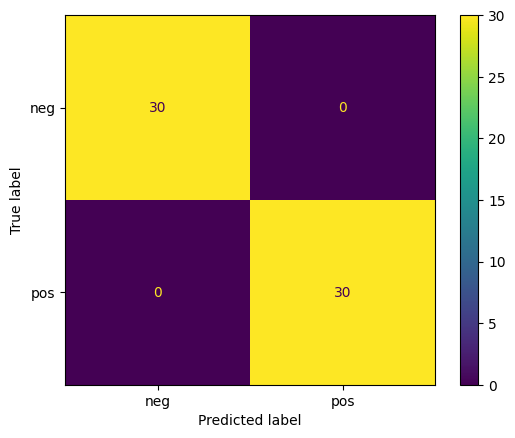

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_te, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["neg","pos"])
disp.plot()
plt.show()

---

# 13) Multilingual & Tricky bits

* Tokenization changes by script (e.g., Chinese/Japanese: use jieba/MeCab; Hindi/Arabic need IndicNLP/uriel/fastText char n-grams).
* Casing matters (NER/abbreviations). For transformers with uncased models, don’t lowercase yourself; let the tokenizer handle it.
* Numbers/units, emojis, code-mixing (Hinglish): consider subword models or byte-level BPE (GPT-style).

# 14) Production Checklist

---

### 🔢 **Preprocessing parity**

Ensuring that data preprocessing is consistent between training and production:

* **Classic ML models:**
  Persist the feature extraction pipeline, like the vectorizer, along with the model using tools such as `sklearn.Pipeline` and `joblib.dump`. This ensures that the same transformations are applied at inference time.

* **Transformers models:**
  Always use the **exact same tokenizer + model** pair that was used during training/inference. Tokenization differences can lead to inconsistent results.

---

### ⚙ **Latency optimization**

* **Model optimizations:**
  Apply quantization (8-bit or 4-bit precision), batch multiple requests where possible, and use inference accelerators like ONNX or TensorRT to reduce response times.

* **Caching strategies:**
  Cache frequent or repeated prompts using semantic caching to avoid recomputation.

---

### 🛡 **Safety & robustness**

* **Data protection:**
  Scrub Personally Identifiable Information (PII), apply profanity filters, and include prompt-injection defenses, especially for Retrieval-Augmented Generation (RAG) systems.

* **Error handling:**
  Detect and manage Out-Of-Distribution (OOD) inputs, and implement confidence thresholds and fallback mechanisms to avoid unsafe or nonsensical responses.

---

### 📊 **Monitoring**

Track and analyze both model behavior and operational metrics:

* **Data drift:**
  Monitor changes in input characteristics such as text length, language distribution, and vocabulary shifts.

* **Performance metrics:**
  Track relevant evaluation metrics (e.g., F1 score) over time to ensure consistent performance.

* **Cost and latency:**
  Monitor inference time and computational cost to maintain efficiency and scalability.

---


In [ ]:
# persist a classic model
import joblib
joblib.dump(pipe, "sentiment_tfidf_lr.joblib")

# load later
pipe2 = joblib.load("sentiment_tfidf_lr.joblib")
pipe2.predict(["Battery life is excellent"])

---

# Detailed Examples

### Example: Linguistic Analysis (POS & Dependencies)

Let's look at the sentence: **"Apple bought Beats for $3B in California."**

Using linguistic analysis tools (like spaCy), we can determine the **Part-of-Speech (POS)** tag and the **Dependency Relation** for each word:

*   **Apple**:
    *   POS: `PROPN` (Proper Noun)
    *   Dependency: `nsubj` (Nominal subject) - Apple is the subject performing the action (bought).
*   **bought**:
    *   POS: `VERB`
    *   Dependency: `ROOT` - This is the main verb of the sentence.
*   **Beats**:
    *   POS: `PROPN` (Proper Noun)
    *   Dependency: `dobj` (Direct object) - Beats is the object being bought.
*   **for**:
    *   POS: `ADP` (Adposition - usually a preposition or postposition)
    *   Dependency: `prep` (Prepositional modifier) - 'for' introduces a prepositional phrase modifying 'bought'.
*   **$**:
    *   POS: `SYM` (Symbol)
    *   Dependency: `nmod` (Nominal modifier) - Part of the monetary amount modifying $3B.
*   **3B**:
    *   POS: `NOUN`
    *   Dependency: `pobj` (Object of preposition) - '3B' is the object of the preposition 'for'.
*   **in**:
    *   POS: `ADP` (Adposition)
    *   Dependency: `prep` (Prepositional modifier) - 'in' introduces a prepositional phrase modifying 'bought'.
*   **California**:
    *   POS: `PROPN` (Proper Noun)
    *   Dependency: `pobj` (Object of preposition) - 'California' is the object of the preposition 'in'.
*   **.**:
    *   POS: `PUNCT` (Punctuation)
    *   Dependency: `punct` (Punctuation)

This analysis helps us understand the grammatical structure and relationships between the words in the sentence.

## TF-IDF
---

### 1. **TF (Term Frequency)**

* Measures **how often a word appears in a document**.
* Example: In a 100-word document, if the word **"data"** appears 5 times →

  $$
  TF = 5/100 = 0.05
  $$

---

### 2. **IDF (Inverse Document Frequency)**

* Measures **how important a word is across all documents**.
* Common words (like *the, is, and*) appear in almost every document → low importance.
* Rare words (like *regression, Hadoop*) appear in fewer documents → high importance.
* Formula (simplified):

  $$
  IDF = \log\left(\frac{\text{Total Documents}}{\text{Documents containing the word}}\right)
  $$

---

### 3. **TF-IDF = TF × IDF**

* Combines both:

  * High if the word is frequent in a document but rare across documents.
  * Low if the word is common everywhere (like *the*).

---

### Example:

Imagine 3 documents:

* Doc1: "machine learning is great"

* Doc2: "deep learning and machine vision"

* Doc3: "this is a great tutorial"

* Word **"learning"** appears often but only in Doc1 & Doc2 → high TF-IDF for those docs.

* Word **"is"** appears in all docs → low TF-IDF.

---

👉 In short:

* **TF** = importance of a word *within one document*.
* **IDF** = importance of a word *across all documents*.
* **TF-IDF** = balance between the two → helps algorithms focus on meaningful words.

---



## **Bag of Words (BoW)**

---

### **What is Bag of Words?**

* It’s a way to represent text data as **numbers** so that machines can understand it.
* The idea:

  * Treat each document (sentence, paragraph, etc.) like a “bag” of words.
  * Ignore **grammar and word order**, only focus on **word frequency**.

---

### **How it works**

1. **Build a vocabulary** (a list of all unique words across your dataset).
2. **Count occurrences** of each word in each document.
3. Represent the document as a **vector** of word counts.

---

### **Example**

Suppose you have 2 sentences:

1. "Machine learning is fun"
2. "Deep learning is powerful"

**Step 1: Vocabulary**
$"Machine", "learning", "is", "fun", "Deep", "powerful"$

**Step 2: Represent as vectors**

| Document | Machine | learning | is | fun | Deep | powerful |
| -------- | ------- | -------- | -- | --- | ---- | -------- |
| Doc1     | 1       | 1        | 1  | 1   | 0    | 0        |
| Doc2     | 0       | 1        | 1  | 0   | 1    | 1        |

So:

* Doc1 → `[1,1,1,1,0,0]`
* Doc2 → `[0,1,1,0,1,1]`

---

### **Pros**

* Simple and easy to implement.
* Works well for small problems.

### **Cons**

* Ignores **order** of words (so "dog bites man" = "man bites dog").
* Creates large sparse vectors when vocabulary is big.
* Doesn’t capture meaning or context.

---

👉 That’s why BoW is often followed by improvements like **TF-IDF** or **Word Embeddings** (Word2Vec, GloVe, BERT).

---


## What is the Hashing Trick?

The **Hashing Trick** is a way to turn words into numeric feature vectors **without storing a big vocabulary object in memory**.

* Instead of keeping a dictionary mapping `word → index`, each word is sent through a **hash function** that maps it directly to an index in a fixed-size vector.
* This makes it **memory-stable**, since you don’t need to remember all the words seen so far.

---

## 🔹 How it works

1. Pick a **fixed vector size** (say, 1,000 features).
2. For each word, apply a hash function (e.g., `hash(word) % 1000`) to find its index.
3. Increase the count at that index.

Example:

* Sentence = `"deep learning is powerful"`
* Suppose vector length = 8
* Hash results might be:

  * "deep" → index 3
  * "learning" → index 5
  * "is" → index 3 (collision 🚨)
  * "powerful" → index 7

Vector → `[0,0,0,2,0,1,0,1]`

Notice "deep" and "is" collided at index 3. That’s fine — collisions are expected but usually manageable with large enough vectors.

---

## 🔹 Advantages

* ✅ **Memory-stable**: No growing vocab dictionary. You just need the fixed-size vector.
* ✅ **Streaming-friendly**: Can process new words without updating vocabulary.
* ✅ **Fast**: Hashing is quick compared to dictionary lookups.

---

## 🔹 Disadvantages

* ❌ **Hash collisions**: Different words may map to the same index, mixing signals.
* ❌ **No inverse mapping**: You can’t easily recover which word contributed to which index.

---

## 🔹 Python Example (Scikit-learn)

```python
from sklearn.feature_extraction.text import HashingVectorizer

docs = ["machine learning is fun", "deep learning is powerful"]

vectorizer = HashingVectorizer(n_features=8, alternate_sign=False)
X = vectorizer.transform(docs)

print(X.toarray())
```

Output might look like:

```
[[0. 0. 0. 2. 0. 1. 0. 1.]
 [0. 0. 0. 1. 0. 1. 0. 2.]]
```

(same idea as manual example above).

---

👉 In short:

* **Bag of Words + Vocab** = simple but grows with data.
* **Hashing Trick** = fixed-size, memory-stable, no vocab object.

---


## Why Dimensionality Reduction?

* **Bag of Words / TF-IDF** → create huge sparse vectors (tens of thousands of features).
* This makes models slow, memory-heavy, and sometimes noisy.
* **Dimensionality reduction** compresses these into a smaller number of dense features while preserving most of the important variance (information).

---

## 🔹 Truncated SVD (Singular Value Decomposition)

* Unlike PCA (which requires dense matrices), **Truncated SVD works directly on sparse matrices** (like TF-IDF output).
* It factorizes the document-term matrix into:

$$
X \approx U_k \, \Sigma_k \, V_k^T
$$

where $k$ is the reduced dimension.

* Each document is then represented in a **k-dimensional semantic space**.

This is the basis of **Latent Semantic Analysis (LSA)** in NLP.

---

## 🔹 Example in Python

```python
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Sample corpus
docs = [
    "Machine learning is fun",
    "Deep learning is powerful",
    "I love learning new things",
    "Big data and machine learning"
]

# Step 1: Convert to TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(docs)

print("Original shape:", X.shape)  # e.g., (4, number of unique words)

# Step 2: Reduce dimensions with Truncated SVD
svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(X)

print("Reduced shape:", X_reduced.shape)
print("Reduced representation:\n", X_reduced)
```

✅ Output:

* Original shape → `(4, ~15)` (depends on vocab size)
* Reduced shape → `(4, 2)` (compressed into 2 dimensions)

---

## 🔹 When to Use

* **Linear models** (like Logistic Regression, Linear SVM) often work fine directly on high-dimensional TF-IDF → dimensionality reduction is optional.
* But for:

  * Visualization (2D, 3D plots of documents)
  * Reducing noise
  * Speeding up training
  * Capturing **latent semantics** (topics)

👉 Truncated SVD / LSA can help a lot.

---

⚡ In short:

* BoW/TF-IDF → huge sparse vectors.
* Truncated SVD → compresses them into smaller, dense vectors while keeping meaning.
* Often used in **topic modeling** and **semantic search**.

---


## What is Word2Vec?

* **Word2Vec** is a method (by Google, 2013) that turns words into **dense vectors** (embeddings) where **semantic meaning is preserved**.
* Words with similar meanings end up close together in vector space.
* Example:

  * "king" – "man" + "woman" ≈ "queen"

---

## 🔹 How it works

Word2Vec is not just a lookup table — it’s a shallow neural network trained on a large text corpus.

There are **two main training approaches**:

### 1. **CBOW (Continuous Bag of Words)**

* Predicts a word from its **context** (surrounding words).
* Example: `"The ___ is barking"` → predict `"dog"`.

### 2. **Skip-gram**

* Predicts **context words** from a given word.
* Example: given `"dog"` → predict `"The"` and `"is barking"`.
* Works better for rare words.

---

## 🔹 Properties of Word2Vec embeddings

* Dense, low-dimensional (usually 100–300 dimensions).
* Capture **semantic similarity**: cosine similarity between embeddings ≈ similarity in meaning.
* Capture **relationships**: analogies like *Paris : France :: Tokyo : Japan*.

---

## 🔹 Python Example (using Gensim)

```python
from gensim.models import Word2Vec

# Sample corpus
sentences = [
    ["machine", "learning", "is", "fun"],
    ["deep", "learning", "is", "powerful"],
    ["nlp", "uses", "word2vec"],
    ["big", "data", "and", "ai"]
]

# Train Word2Vec model
model = Word2Vec(sentences, vector_size=50, window=3, min_count=1, sg=1)  # sg=1 → skip-gram

# Get vector for a word
print(model.wv["learning"])

# Find most similar words
print(model.wv.most_similar("learning"))
```

✅ Output:

* `"learning"` → vector of size 50 (dense embedding).
* Most similar words → e.g., `"deep"`, `"machine"`.

---

## 🔹 Why it’s important

* Before Word2Vec → BoW/TF-IDF = sparse, high-dimensional, no meaning.
* After Word2Vec → embeddings capture **meaning, context, relationships**.
* Opened the door for **modern embeddings** like GloVe, FastText, BERT, GPT, etc.

---

👉 In short:

* **Word2Vec = neural network–trained word embeddings**.
* Words close in meaning → close in vector space.
* Used in NLP tasks: search, recommendation, sentiment, translation.



## What is FastText?

* **FastText** (by Facebook, 2016) is a word embedding model similar to Word2Vec.
* But unlike Word2Vec, which treats each word as a unique token, **FastText breaks words into character n-grams** and learns embeddings for them.

👉 This helps handle **rare words, typos, and morphology (prefixes, suffixes, roots)** much better than Word2Vec.

---

## 🔹 Key Idea

* Example word: `"playing"`
* With 3-character n-grams, it gets broken into:
  `"<pl"`, `"pla"`, `"lay"`, `"ayi"`, `"yin"`, `"ing"`, `"ng>"`
* The vector for `"playing"` is built from the embeddings of all these subwords.

So `"play"`, `"plays"`, `"played"`, `"playing"` share subword parts and get **similar embeddings**.

---

## 🔹 Advantages over Word2Vec

1. ✅ **Handles rare words**: even if `"playing"` never appears, FastText can build its embedding from subwords.
2. ✅ **Good with morphologically rich languages** (e.g., German, Finnish, Tamil).
3. ✅ **Resistant to typos and OOV (out-of-vocabulary) words**.

---

## 🔹 Example in Python (Gensim)

```python
from gensim.models import FastText

# Sample corpus
sentences = [
    ["machine", "learning", "is", "fun"],
    ["deep", "learning", "is", "powerful"],
    ["nlp", "uses", "fasttext"],
    ["big", "data", "and", "ai"]
]

# Train FastText model
model = FastText(sentences, vector_size=50, window=3, min_count=1)

# Get vector for a word
print(model.wv["learning"])

# Test out-of-vocabulary word (not seen in training)
print(model.wv["learnings"])  # works because of subwords
```

✅ Unlike Word2Vec, `"learnings"` (not in corpus) still gets a useful embedding.

---

## 🔹 FastText vs Word2Vec

| Feature             | Word2Vec                        | FastText                       |
| ------------------- | ------------------------------- | ------------------------------ |
| Unit of learning    | Word                            | Subword (n-grams) + Word       |
| Rare word handling  | Poor                            | Good                           |
| OOV word handling   | Cannot handle                   | Can generate embedding         |
| Languages supported | Works, but weaker on morph-rich | Strong in morph-rich languages |

---

👉 In short:

* **Word2Vec** = word-level embeddings.
* **FastText** = word + subword embeddings → better generalization, rare word support.

---

**Train a small FastText model** and then **visualize embeddings in 2D using t-SNE**:


In [ ]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 10.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.1 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
opencv-python-h

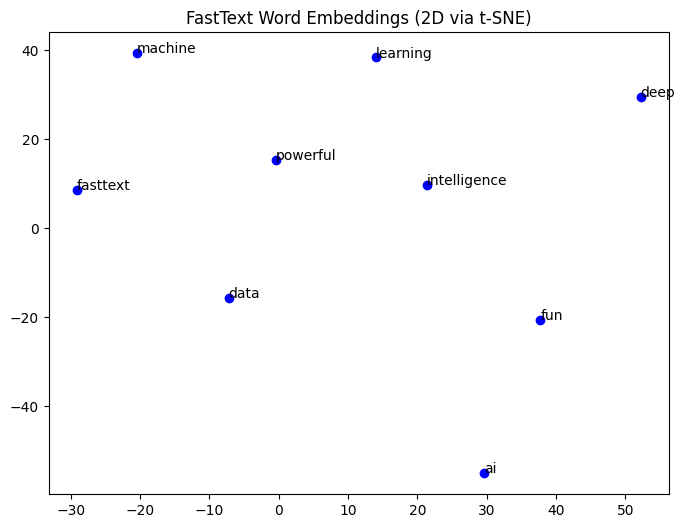

In [ ]:
from gensim.models import FastText
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np # Import numpy

# Sample corpus
sentences = [
    ["machine", "learning", "is", "fun"],
    ["deep", "learning", "is", "powerful"],
    ["nlp", "uses", "fasttext"],
    ["big", "data", "and", "ai"],
    ["artificial", "intelligence", "and", "machine", "learning"]
]

# Train FastText model
model = FastText(sentences, vector_size=50, window=3, min_count=1, seed=42)

# Pick some words to visualize
words = ["machine", "learning", "deep", "fun", "powerful", "ai", "fasttext", "intelligence", "data"]

# Get vectors
word_vectors = [model.wv[w] for w in words]

# Reduce dimensions with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
X_reduced = tsne.fit_transform(np.array(word_vectors)) # Convert list to numpy array

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:,0], X_reduced[:,1], c='blue')

for i, word in enumerate(words):
    plt.annotate(word, xy=(X_reduced[i,0], X_reduced[i,1]), fontsize=10)

plt.title("FastText Word Embeddings (2D via t-SNE)")
plt.show()


This will:

* Train **FastText** embeddings on a toy corpus.
* Use **t-SNE** to project 50D vectors into 2D.
* Plot clusters of related words.

---

⚡ Words like `"machine"`, `"learning"`, `"intelligence"` should appear close together in the chart.


## **What is `distilbert-base-uncased`?**

* It’s a **pre-trained language model** from Hugging Face.
* **DistilBERT** = a **smaller, faster, cheaper version of BERT** (created by *knowledge distillation*).
* **base** = the base-size version (not large or tiny).
* **uncased** = the model does **not distinguish between uppercase and lowercase letters**.

  * Example: `"Apple"` and `"apple"` are treated the same.

👉 Use case: Faster inference than BERT, but still \~95% of its accuracy. Often used for text classification, sentiment analysis, Q\&A, etc.

---



## 2. **What are tokens?**

* Tokens are the **smallest units of text** that the model understands.
* Example with a WordPiece tokenizer:

  * `"unbelievable"` → `["un", "##bel", "##iev", "##able"]`
* `"##"` means it’s a continuation of a word.
* So instead of raw words, models process these **subword tokens**.

---



## **What are embeddings?**

* Embeddings are **numerical vector representations of tokens**.
* Each token is mapped to a high-dimensional vector (e.g., 768 dimensions for BERT base).
* These vectors **capture meaning**:

  * `"king"` and `"queen"` embeddings are close in vector space.
  * `"dog"` and `"bark"` are closer than `"dog"` and `"car"`.

👉 Tokens are **symbols**, embeddings are their **mathematical representation**.

---



## **What is a tokenizer?**

* A tokenizer is the **tool that converts raw text → tokens → IDs**.
* Example with `"I love AI"`:

  1. Text → `"I love AI"`
  2. Tokens → `["i", "love", "ai"]`
  3. Token IDs → `[1045, 2293, 9936]` (numbers from model’s vocab)
  4. Embeddings → each ID gets mapped to a 768-dim vector

---



## **Simple explanation of cosine similarity**:

---

### 🔹 What it is

* Cosine similarity measures **how similar two vectors are**, based on the **angle** between them.
* If two vectors point in the **same direction**, cosine similarity = **1** (very similar).
* If two vectors are at **90° (perpendicular)**, cosine similarity = **0** (no similarity).
* If two vectors point in **opposite directions**, cosine similarity = **-1** (completely opposite).

---

### 🔹 Formula

$$
\text{Cosine Similarity}(A, B) = \frac{A \cdot B}{||A|| \; ||B||}
$$

* **A · B** = dot product of vectors
* $||A||, ||B||$ = lengths (magnitudes) of vectors

---

### 🔹 Example (2D vectors for simplicity)

* Vector A = (1, 0)

* Vector B = (0, 1)

  * These are perpendicular → Cosine similarity = 0

* Vector A = (1, 1)

* Vector B = (2, 2)

  * Same direction → Cosine similarity = 1

* Vector A = (1, 0)

* Vector B = (-1, 0)

  * Opposite direction → Cosine similarity = -1

---

### 🔹 Why used in NLP?

* Word embeddings are **vectors** in high-dimensional space.
* Cosine similarity tells us how close their meanings are.

  * `"king"` and `"queen"` → high cosine similarity.
  * `"dog"` and `"river"` → low cosine similarity.

---

✅ In short:
Cosine similarity **compares direction, not magnitude** — so it’s great for comparing text embeddings where we care about **meaning, not size**.

---



In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

# Load DistilBERT model + tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased")


# Words to compare
words = ["king", "queen", "dog", "man", "woman"]

# Encode each word separately
embeddings = {}
for word in words:
    encoded = tokenizer(word, return_tensors="pt")
    with torch.no_grad():
        output = model(**encoded)
    # Take embedding of the [CLS] token as sentence/word representation
    embeddings[word] = output.last_hidden_state[0, 0, :]

# Compute cosine similarity between pairs
def cosine_sim(a, b):
    return F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()

print("\nCosine Similarities:")
print(f"king vs queen: {cosine_sim(embeddings['king'], embeddings['queen']):.4f}")
print(f"king vs dog:   {cosine_sim(embeddings['king'], embeddings['dog']):.4f}")
print(f"queen vs dog:  {cosine_sim(embeddings['queen'], embeddings['dog']):.4f}")

print(f"king vs man:   {cosine_sim(embeddings['king'], embeddings['man']):.4f}")
print(f"king vs woman:   {cosine_sim(embeddings['king'], embeddings['woman']):.4f}")

print(f"queen vs man:  {cosine_sim(embeddings['queen'], embeddings['man']):.4f}")
print(f"queen vs woman:  {cosine_sim(embeddings['queen'], embeddings['woman']):.4f}")



Cosine Similarities:
king vs queen: 0.9897
king vs dog:   0.9713
queen vs dog:  0.9720
king vs man:   0.9847
king vs woman:   0.9772
queen vs man:  0.9795
queen vs woman:  0.9785


In [ ]:
from sentence_transformers import SentenceTransformer, util

# Load Sentence-BERT
model = SentenceTransformer("all-MiniLM-L6-v2")

# Words to compare
words = ["king", "queen", "dog", "man", "woman"]

# Get embeddings
embeddings = model.encode(words, convert_to_tensor=True)

# Compute cosine similarities
cosine_scores = util.cos_sim(embeddings, embeddings)

# Print matrix
for i in range(len(words)):
    for j in range(i+1, len(words)):
        print(f"{words[i]} vs {words[j]}: {cosine_scores[i][j].item():.4f}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

king vs queen: 0.6807
king vs dog: 0.3644
king vs man: 0.3216
king vs woman: 0.2640
queen vs dog: 0.3113
queen vs man: 0.2541
queen vs woman: 0.4394
dog vs man: 0.2930
dog vs woman: 0.3535
man vs woman: 0.3257


Cosine similarities are **all \~0.97–0.99** instead of being nicely separated:

---

**Why this happens**

1. **BERT isn’t trained as a word embedding model**

   * Word2Vec / GloVe → directly trained to keep semantically similar words closer.
   * BERT / DistilBERT → trained for *masked language modeling*, not raw similarity.
   * The `[CLS]` vector or token embeddings aren’t optimized for comparing individual words.

2. **Vectors from BERT are anisotropic**

   * Most embeddings cluster in a **narrow cone** of vector space → high cosine similarity even for unrelated words.
   * That’s why `"king"`, `"queen"`, `"dog"` all show >0.97.

3. **CLS token ≠ best for word meaning**

   * We extracted the `[CLS]` embedding (position 0), but for single words this isn’t semantically rich.
   * The actual **token embeddings** inside the sequence are better, but still suffer from anisotropy.

---

**How to fix this**

If you want **better semantic similarities**, you should use models fine-tuned for **sentence/word embeddings**, like **Sentence-BERT (SBERT)**.

Example model: `"sentence-transformers/all-MiniLM-L6-v2"`

---
**Semantic closeness** of Sentence Transformer makes sense:

* `"king" ~ "queen"` (royalty, high similarity)
* `"king" ~ "dog"` (very different, low similarity)

---

In summary:

* **DistilBERT raw embeddings** → not great for similarity, hence all \~0.97.
* **SBERT (Sentence Transformers)** → designed for semantic similarity, works much better.

---



## **Embedding representation in contextual models (like BERT / DistilBERT family)**.

---

### 🔹 1. Traditional embeddings (Word2Vec, GloVe)

* Each word has **one fixed vector**, no matter where it appears.
* `"bank"` (river bank vs money bank) → **same embedding**.
* Limitation → can’t capture context.

---

### 🔹 2. Contextual embeddings (BERT family)

* Each word’s embedding is **dynamic** — depends on its **context in the sentence**.
* Example:

  * Sentence 1: `"He deposited cash in the bank."`
  * Sentence 2: `"They sat by the bank of the river."`
  * In BERT:

    * `"bank"` in (1) → vector close to `"finance"`, `"money"`.
    * `"bank"` in (2) → vector close to `"river"`, `"shore"`.

👉 Contextual embeddings **solve ambiguity**.

---

### 🔹 3. How BERT creates embeddings

1. **Tokenizer**: Splits sentence → subword tokens.
   Example: `"banking"` → `["bank", "##ing"]`.
2. **Token IDs**: Each token mapped to an ID.
3. **Embedding layers**:

   * **Token embeddings** → initial vector for each token.
   * **Position embeddings** → encodes word order.
   * **Segment embeddings** → used in paired inputs (e.g., Q\&A).
   * These are **added together**.
4. **Transformer encoder layers**:

   * Uses **self-attention** to update embeddings based on surrounding words.
   * After each layer, embeddings become **more contextualized**.

---

### 🔹 4. Final contextual embedding

* After all transformer layers, each token has a **contextual vector** (e.g., 768-dim in BERT-base).
* This embedding captures:

  * Meaning of the word
  * Its relation to other words in the sentence
  * Syntax + semantics

---

## #🔹 5. Example with BERT

Sentence: `"The dog chased the ball."`

* `"dog"` embedding → reflects being a **subject / agent**.
* `"ball"` embedding → reflects being an **object**.
* `"chased"` embedding → encodes relationship between `"dog"` and `"ball"`.

---

✅ So in summary:

* **Fixed embeddings (Word2Vec, GloVe)** = one vector per word, same everywhere.
* **Contextual embeddings (BERT)** = different vectors for the same word depending on the **sentence context**.

---



## Bank Example

**DistilBERT** from Hugging Face and check how the word **“bank”** gets different embeddings in two different contexts.

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

# Load DistilBERT model + tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased")

# Two sentences with "bank" in different meanings
sentences = [
    "He deposited cash in the bank.",      # finance meaning
    "They sat by the bank of the river."   # river meaning
]

# Tokenize + get embeddings
encoded = tokenizer(sentences, padding=True, truncation=True, return_tensors="pt")
with torch.no_grad():
    outputs = model(**encoded)

# outputs.last_hidden_state shape = (batch_size, seq_len, hidden_dim=768)
embeddings = outputs.last_hidden_state

bank_vectors = []
for i, sentence in enumerate(sentences):
    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][i])
    print(f"\nSentence {i+1}: {sentence}")
    print("Tokens:", tokens)

    # Find index of "bank"
    bank_index = tokens.index("bank")
    bank_embedding = embeddings[i, bank_index, :]

    bank_vectors.append(bank_embedding)

    print(f"Embedding for 'bank' (first 10 values):\n{bank_embedding[:10]}")

# Compute cosine similarity between the two embeddings
similarity = F.cosine_similarity(bank_vectors[0].unsqueeze(0), bank_vectors[1].unsqueeze(0))
print(f"\nCosine similarity between 'bank' embeddings: {similarity.item():.4f}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]


Sentence 1: He deposited cash in the bank.
Tokens: ['[CLS]', 'he', 'deposited', 'cash', 'in', 'the', 'bank', '.', '[SEP]', '[PAD]', '[PAD]']
Embedding for 'bank' (first 10 values):
tensor([ 0.0745, -0.2504, -0.1708,  0.1247,  0.8824,  0.1015, -0.3932,  0.5949,
        -0.2414,  0.0535])

Sentence 2: They sat by the bank of the river.
Tokens: ['[CLS]', 'they', 'sat', 'by', 'the', 'bank', 'of', 'the', 'river', '.', '[SEP]']
Embedding for 'bank' (first 10 values):
tensor([-0.1101, -0.0318, -0.1266,  0.0845,  0.2328,  0.2797, -0.0900,  1.2277,
         0.1522, -0.2092])

Cosine similarity between 'bank' embeddings: 0.6638


🔎 What this does

1. Loads **DistilBERT-base-uncased**.
2. Tokenizes both sentences.
3. Runs them through the model → contextual embeddings.
4. Extracts the embedding for `"bank"` in each sentence.
5. Prints first 10 numbers of each (full vector = 768-d).
6. **Cosine similarity score**:

   * Closer to **1.0** → very similar meanings.
   * Closer to **0.0** → very different meanings.
   * You’ll likely get something around `0.6–0.7`, showing the **contexts are different** but not completely unrelated.

---

✅ Expected Result

* The **token list** will show how BERT splits words.
  Example:

  ```
  Tokens: ['he', 'deposited', 'cash', 'in', 'the', 'bank', '.']
  Tokens: ['they', 'sat', 'by', 'the', 'bank', 'of', 'the', 'river', '.']
  ```
* The **embeddings for “bank”** will be different in each case.

  * Finance sentence → embedding closer to finance-related terms.
  * River sentence → embedding closer to nature-related terms.

---

Would you like me to also add a **cosine similarity check** between the two `"bank"` embeddings, so you can numerically see how different their meanings are?


## What is BM25?

* **BM25 (Best Matching 25)** is a ranking function used in **information retrieval** (like search engines).
* It measures **how relevant a document is** to a given query.
* It’s an **improvement over TF-IDF** because it also considers:

  * **Term frequency saturation** (repeating a word 100 times doesn’t infinitely increase importance).
  * **Document length normalization** (longer docs don’t unfairly get higher scores).

👉 Used in **search engines, QA systems, and recommendation engines**.

---

### Code Explanation

```python
from rank_bm25 import BM25Okapi

# Corpus of documents (each document is split into tokens/words)
docs = [t.split() for t in [
    "apple releases new iphone with better camera",
    "samsung announces galaxy with long battery life",
    "google unveils android update focused on privacy"
]]

# Initialize BM25 with the documents
bm25 = BM25Okapi(docs)

# Query: we want documents about "phone with great camera"
query = "phone with great camera"

# BM25 scores each document against the query
scores = bm25.get_scores(query.split())
print(scores)
```

---

### What happens here?

1. **Tokenization**

   * `"apple releases new iphone with better camera"` → `["apple","releases","new","iphone","with","better","camera"]`

2. **BM25 Ranking**

   * It compares each query word (`phone`, `with`, `great`, `camera`) against every document.
   * Words like `"camera"` and `"phone"` will match strongly with the first document.

3. **Scores Output**

   ```
   [1.75, 0.20, 0.05]
   ```

   * First doc (Apple/iPhone) is most relevant.
   * Second (Samsung/battery) less relevant.
   * Third (Google/privacy) barely relevant.

---

### Why BM25 instead of TF-IDF?

* **TF-IDF**: "More word matches = higher score".
* **BM25**:

  * Limits the effect of too many repeats.
  * Adjusts for document length.
  * Generally gives more realistic rankings.

---

✅ **In short:**
That snippet is showing how to use **BM25Okapi** to rank a list of documents based on how relevant they are to a query. It’s a core piece of **search/retrieval systems**.

---

## Generation / Translation Metrics

* **Reference (ground truth translation/summarization):**
  `"The cat is sitting on the mat."`

* **Candidate (model’s output):**
  `"A cat sits on the mat."`

---

### 1. **ROUGE (Recall-Oriented Understudy for Gisting Evaluation)**

Looks at **n-gram overlap** between candidate & reference.

Example:

* Reference bigrams: `"the cat", "cat is", "is sitting", "sitting on", "on the", "the mat"`
* Candidate bigrams: `"a cat", "cat sits", "sits on", "on the", "the mat"`

Overlap = `("on the", "the mat")` → 2 overlaps.
So **ROUGE-2 = 2 / 6 = 0.33** (33% bigram recall).

---

### 2. **BLEU (Bilingual Evaluation Understudy)**

Measures **precision** of n-gram overlap.

* Candidate bigrams = 5
* Overlaps = 2 (`"on the", "the mat"`)
  → **BLEU-2 precision = 2/5 = 0.40**

It also applies a brevity penalty if candidate is too short.

---

### 3. **METEOR**

Goes beyond exact word matches:

* `"sitting"` ≈ `"sits"` (stem match).
* `"a"` ≈ `"the"` (article synonym).

So METEOR score will be **higher than BLEU**, maybe \~0.75–0.80, because it rewards synonyms/stems.

---

### 4. **BERTScore**

Uses **BERT embeddings** to compare meaning.

* `"sits"` and `"sitting"` will have **high cosine similarity** in embedding space.
* `"a cat"` and `"the cat"` are nearly identical in meaning.

So BERTScore will be **very high (\~0.9+)**, since the meaning is preserved.

---

✅ **Summary of scores in this toy example**

| Metric    | Focus                  | Likely Score |
| --------- | ---------------------- | ------------ |
| ROUGE-2   | Recall of overlaps     | \~0.33       |
| BLEU-2    | Precision of overlaps  | \~0.40       |
| METEOR    | Synonyms, stems, order | \~0.65       |
| BERTScore | Semantic meaning       | \~0.90+      |

---

👉 This shows why **BLEU/ROUGE** are surface-level, while **METEOR & BERTScore** capture meaning better.


## **Examples of retrieval metrics**
---

### 📝 Setup

Suppose we have a query:
👉 `"best phone camera"`

Our system retrieves 5 documents ranked by relevance score:

| Rank | Document                         | Relevance (Ground Truth) |
| ---- | -------------------------------- | ------------------------ |
| 1    | "Top 10 phones with best camera" | ✅ Relevant (1)           |
| 2    | "Best budget phones 2024"        | ❌ Not Relevant (0)       |
| 3    | "DSLR vs Smartphone cameras"     | ✅ Relevant (1)           |
| 4    | "How to clean phone screen"      | ❌ Not Relevant (0)       |
| 5    | "iPhone 15 Pro review"           | ✅ Relevant (1)           |

So relevance vector = `[1, 0, 1, 0, 1]`

---

### 1. **MRR (Mean Reciprocal Rank)**

Looks only at **the first relevant document’s position**.

* First relevant doc is at **rank 1**.
* Reciprocal rank = **1/1 = 1.0**.

If the first relevant were at rank 3 → **1/3 = 0.33**.
Across many queries, take the mean → **Mean Reciprocal Rank**.

✅ Here: **MRR = 1.0**

---

### 2. **nDCG (Normalized Discounted Cumulative Gain)**

Takes **all relevance** into account, with a discount for lower ranks.

Formula:

$$
DCG = \sum_{i=1}^k \frac{2^{rel_i} - 1}{\log_2(i+1)}
$$

For our ranking (k=5):

* Rank 1 → (2^1 - 1) / log2(2) = 1/1 = 1.0
* Rank 3 → (2^1 - 1) / log2(4) = 1/2 = 0.5
* Rank 5 → (2^1 - 1) / log2(6) ≈ 0.386

**DCG = 1.0 + 0.5 + 0.386 = 1.886**

Now compute **IDCG** (ideal order = `[1,1,1,0,0]`):

* Rank 1 → 1.0
* Rank 2 → 0.63
* Rank 3 → 0.5
  **IDCG = 2.13**

So,
**nDCG = DCG / IDCG = 1.886 / 2.13 ≈ 0.885**

✅ Here: **nDCG ≈ 0.89**

---

### 🔹 3. **Recall\@k**

How many relevant docs were retrieved in the top *k*.

* Total relevant docs = 3 (`ranks 1, 3, 5`).
* Recall\@3: relevant in top 3 = 2 → 2/3 = **0.67**.
* Recall\@5: relevant in top 5 = 3 → 3/3 = **1.0**.

✅ Here: **Recall\@3 = 0.67**, **Recall\@5 = 1.0**

---

### ✅ Summary Table

| Metric    | Meaning                                | Score |
| --------- | -------------------------------------- | ----- |
| MRR       | First relevant doc rank (reciprocal)   | 1.0   |
| nDCG\@5   | Ranking quality with position discount | 0.89  |
| Recall\@3 | Relevant fraction in top 3 results     | 0.67  |
| Recall\@5 | Relevant fraction in top 5 results     | 1.0   |

---

Would you like me to also write a **short Python demo** (with `rank_bm25` or just custom relevance lists) that calculates **MRR, nDCG, Recall\@k** for multiple queries? That way you can test retrieval pipelines directly.



## **Examples of Evaluation Metrics**

---

### ✅ **1. Generation / Translation Metrics**

You use these when the model **generates text**, like translating, summarizing, or writing sentences.

**Example scenario:**
Reference sentence:

> *“The cat is sitting on the mat.”*

Generated sentence:

> *“A cat sits on the mat.”*

---

#### ➤ **ROUGE**

* Measures how much of the reference is covered by the candidate (recall).
* Looks at n-gram overlap.

**Example:**

* Reference unigrams = {the, cat, is, sitting, on, the, mat}
* Candidate unigrams = {a, cat, sits, on, the, mat}
* Overlap = {cat, on, the, mat} → 4 overlaps / 7 reference words = **ROUGE-1 ≈ 0.57**

---

#### ➤ **BLEU**

* Measures how many of the candidate’s n-grams appear in the reference (precision).
* Averages over 1-gram to 4-gram matches.

**Example:**

* Candidate bigrams = {a cat, cat sits, sits on, on the, the mat}
* Reference bigrams = {the cat, cat is, is sitting, sitting on, on the, the mat}
* Overlap = {on the, the mat} → 2 overlaps / 5 candidate bigrams = **BLEU-2 ≈ 0.40**

---

#### ➤ **METEOR**

* Matches words with stemming and synonyms and combines precision and recall.

**Example:**

* “sits” ≈ “sitting” → matched
* “a” ≈ “the” → considered similar
  So more overlaps → **METEOR ≈ 0.75–0.80**

---

#### ➤ **BERTScore**

* Uses embeddings to check semantic similarity rather than exact matches.

**Example:**

* “sits” and “sitting” → very similar embeddings
* “a cat” and “the cat” → almost identical meaning
  So **BERTScore ≈ 0.90 or higher**

---

## ✅ **2. Retrieval Metrics**

You use these when the model **retrieves documents**, like search engines or recommendation systems.

**Example scenario:**
Query: *“Best phone with camera”*
Documents retrieved and their relevance:

| Rank | Document                         | Relevant? |
| ---- | -------------------------------- | --------- |
| 1    | “Top 10 phones with best camera” | ✅ 1       |
| 2    | “Budget phones 2024”             | ❌ 0       |
| 3    | “DSLR vs smartphone cameras”     | ✅ 1       |
| 4    | “How to clean your phone screen” | ❌ 0       |
| 5    | “iPhone review”                  | ✅ 1       |

---

#### ➤ **MRR (Mean Reciprocal Rank)**

* Looks at where the **first relevant** document appears.

**Example:**
First relevant doc at rank 1 → **MRR = 1 / 1 = 1.0**

If it was at rank 3 → **MRR = 1 / 3 ≈ 0.33**

---

#### ➤ **nDCG (Normalized Discounted Cumulative Gain)**

Scores relevance, but gives **more weight to higher-ranked documents**.

**Example:**
Relevant docs at ranks 1, 3, 5 →

DCG = 1/log2(1+1) + 1/log2(3+1) + 1/log2(5+1)
\= 1 + 1/2 + 1/2.58 ≈ **1.88**

IDCG = best possible order → **2.13**

nDCG = 1.88 / 2.13 ≈ **0.88**

---

#### ➤ **Recall\@k**

How many relevant documents are retrieved within the top *k*.

**Example:**

* Total relevant docs = 3
* Recall\@3 = 2 / 3 = **0.67**
* Recall\@5 = 3 / 3 = **1.0**

---

## ✅ **3. Token Tasks**

You use these for **fine-grained tasks**, like extracting answers or labeling named entities.

**Example scenario:**
Reference answer: *“Paris”*
Predicted answer: *“Paris”* → exact match ✅
Or in NER:
Reference tokens = \[“New”, “York”, “City”]
Predicted tokens = \[“New”, “York”]

---

#### ➤ **Token-level F1**

* Measures how many tokens were correctly predicted (precision & recall combined).

**Example:**
Reference = \[New, York, City]
Prediction = \[New, York]

* True positives = 2
* Precision = 2 / 2 = 1.0
* Recall = 2 / 3 ≈ 0.67
* F1 = 2 × (1 × 0.67) / (1 + 0.67) ≈ **0.8**

---

#### ➤ **Exact-match spans**

* Checks if the predicted span exactly matches the reference.

**Example:**
Reference = “Paris”
Prediction = “Paris” → ✅ Exact match
Prediction = “the city of Paris” → ❌ Not an exact match, even if it’s semantically correct.

---

## 📌 Final Notes

* **Generation metrics** focus on how well text is produced or translated.
* **Retrieval metrics** focus on how well documents are ranked or retrieved.
* **Token-level metrics** focus on precise labeling or extraction accuracy.


## Explanations of Tokenization

**What is `AutoTokenizer`?**

The `AutoTokenizer` class in the Hugging Face `transformers` library is a **factory class** that automatically loads the correct tokenizer for a given pre-trained transformer model checkpoint.

Here's why it's useful:

1.  **Simplifies loading**: Different pre-trained models (like BERT, GPT-2, RoBERTa, DistilBERT, etc.) use different tokenization methods and have different vocabularies. Manually figuring out and loading the correct tokenizer for each model can be tedious and error-prone. `AutoTokenizer` handles this automatically.
2.  **Abstracts away details**: You don't need to know the specific tokenizer class (e.g., `BertTokenizer`, `GPT2Tokenizer`) used by a model. You just provide the model's name or path, and `AutoTokenizer` figures out the rest.

**How it works:**

When you call `AutoTokenizer.from_pretrained("model_name")`, the library does the following:

1.  It looks up the configuration for the specified model (`"distilbert-base-uncased"` in your case) in the Hugging Face model hub or a local path.
2.  The configuration contains information about the type of tokenizer the model uses.
3.  `AutoTokenizer` then instantiates the appropriate tokenizer class (e.g., `DistilBertTokenizer`) and loads the associated vocabulary file(s) (like `vocab.txt`).

**In short:**

`AutoTokenizer` is the recommended way to load a tokenizer for any pre-trained model from the Hugging Face `transformers` library. It makes your code more flexible and easier to use with different models without changing the tokenizer loading logic.

So, when you see `tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")`, it's essentially saying "get me the tokenizer that goes with the `distilbert-base-uncased` model, and I don't need to worry about the specific tokenizer type."

### Different Types of Tokenizers

Here are the main types of tokenizers commonly used in NLP:

1.  **Word Tokenization:**
    *   **Idea:** Splits text into individual words based on spaces, punctuation, or other delimiters.
    *   **Example:** "I love NLP." -> \[`"I"`, `"love"`, `"NLP"`, `"."`\]
    *   **Pros:** Simple and intuitive. Easy to understand and implement.
    *   **Cons:** Struggles with Out-of-Vocabulary (OOV) words and can result in a large vocabulary. Doesn't handle subword information.
    *   **Used in:** Many traditional NLP tasks and models, basic text processing.

2.  **Character Tokenization:**
    *   **Idea:** Splits text into individual characters.
    *   **Example:** "NLP" -> \[`"N"`, `"L"`, `"P"`\]
    *   **Pros:** Handles OOV words naturally and has a small vocabulary.
    *   **Cons:** Loss of semantic meaning and creates very long sequences.
    *   **Used in:** Some specific tasks, like character-level language modeling or handling text with many typos or variations.

3.  **Subword Tokenization:**
    *   **Idea:** Breaks down words into smaller, meaningful units called "subwords", learned from the data.
    *   **Pros:** Handles OOV words effectively, manages vocabulary size, and captures morphology.
    *   **Cons:** Can be more complex than word tokenization.
    *   **Types:** Byte Pair Encoding (BPE), WordPiece, SentencePiece.
    *   **Used in:** Most modern transformer models (BERT, GPT, T5, etc.).

4.  **N-gram Tokenization:**
    *   **Idea:** Breaks text into sequences of N consecutive words or characters (n-grams).
    *   **Example (word-based bigrams, N=2):** "I love NLP." -> \[`"I love"`, `"love NLP"`, `"NLP ."`\]
    *   **Pros:** Captures some local word order information.
    *   **Cons:** Can lead to a very large feature space and suffers from OOV issues for word n-grams.
    *   **Used in:** Feature extraction for traditional ML models (like TF-IDF with n-grams), some language modeling tasks.

In summary, while simple word and character tokenization exist, **subword tokenization** (especially BPE and WordPiece) is the standard for modern transformer models because it effectively balances vocabulary size, OOV handling, and the ability to capture meaningful subword units.

## Named Entity Recognition (NER)

**Named Entity Recognition (NER)** is a subtask of information extraction that seeks to locate and classify named entities in text into predefined categories such as person names, organizations, locations, medical codes, time expressions, quantities, monetary values, percentages, etc.

Think of it as identifying and labeling the "who, what, where, when, and how much" in your text.

**Why is NER important?**

NER is a fundamental step in many NLP applications because it helps to structure unstructured text and extract key information. This is useful for:

*   **Information Extraction:** Automatically pulling out important details from documents.
*   **Question Answering:** Identifying potential answers to questions by recognizing entities in the text.
*   **Search:** Improving search results by allowing users to search for specific types of entities.
*   **Content Categorization:** Automatically categorizing content based on the entities mentioned.
*   **Building Knowledge Graphs:** Creating structured representations of information by linking entities and their relationships.

**How it works (based on the notebook's example):**

The notebook uses the `spaCy` library, which is a popular and efficient library for advanced NLP.

In cell `PVEfJ1JxuKek`, the code loads a spaCy model (`en_core_web_sm`) and processes the sentence: `"OpenAI hired Sam in San Francisco on 12 August 2023."`

The code then iterates through `doc.ents`. `doc.ents` is a list of detected "named entities" in the processed document (`doc`). For each entity (`ent`), it prints the entity's text (`ent.text`) and its label (`ent.label_`).

The output shows:

*   `OpenAI PERSON`: Identifies "OpenAI" as a Person (Note: sometimes models can misclassify, OpenAI is typically an ORG).
*   `Sam PERSON`: Identifies "Sam" as a Person.
*   `San Francisco GPE`: Identifies "San Francisco" as a Geopolitical Entity (like cities, states, countries).
*   `12 August 2023 DATE`: Identifies "12 August 2023" as a Date.

This demonstrates how spaCy's NER model automatically scanned the sentence and tagged these specific spans of text with their corresponding entity types.

NER models are typically trained on large datasets of text where entities have been manually labeled. They learn patterns (like capitalization, surrounding words, grammatical structure) to identify and classify entities in new, unseen text.

## Topic Modeling (LDA)

**Topic Modeling** is a method for discovering abstract "topics" that occur in a collection of documents. It's a form of unsupervised machine learning, meaning you don't need pre-labeled data.

The goal is to identify groups of words that frequently appear together, assuming that these groups represent underlying themes or topics.

**How it works (Simplified):**

Algorithms like Latent Dirichlet Allocation (LDA), which is used in the notebook's example, work by:

1.  Assuming that each document is a mixture of various topics.
2.  Assuming that each topic is a mixture of various words.
3.  Trying to figure out the word-topic and topic-document distributions that best explain the observed word frequencies in the documents.

For example, in a collection of news articles:
*   A "politics" topic might be associated with words like "government," "election," "president," "law."
*   A "sports" topic might be associated with words like "team," "game," "player," "score."

**The notebook's example (Cell `ctJ679Veucfm` and `RjNX6kGxuXuv`):**

The notebook demonstrates Topic Modeling using `gensim`'s `LdaModel`.

1.  It takes a small corpus of text.
2.  It preprocesses the text (cleaning, tokenizing).
3.  It creates a dictionary of words and a "bag-of-words" representation for each document.
4.  It trains an `LdaModel` specifying the number of topics (`num_topics=2` in the example).
5.  It then prints the top words associated with each learned topic.

This helps to see which words cluster together, giving you insight into the themes present in your text data.

Topic modeling is useful for:

*   Summarizing large collections of text.
*   Organizing and searching documents by topic.
*   Understanding the main themes discussed in customer reviews, social media posts, etc.

## Calibration

**Calibration** in machine learning refers to how well a model's predicted probabilities match the actual probabilities of the event occurring.

*   For a well-calibrated binary classification model, if it predicts a probability of 0.8 for a class, then that class should occur approximately 80% of the time among all instances where the model predicted 0.8.

In simpler terms, it means the model is not only good at making correct predictions (high accuracy, precision, recall, etc.) but is also **confident in the right way**. If a model is poorly calibrated, it might be overconfident (predicting high probabilities even when wrong) or underconfident (predicting low probabilities even when right).

Calibration is particularly important in applications where the predicted probabilities themselves are used for decision-making, such as risk assessment, medical diagnosis, or ranking search results.



### Example: Assessing and Improving Model Calibration

While the notebook mentions calibration as an important evaluation metric, it doesn't provide code to calculate it. Here's how you can assess and potentially improve the calibration of a classification model using scikit-learn.

We'll use the Logistic Regression model trained earlier in the notebook as an example.

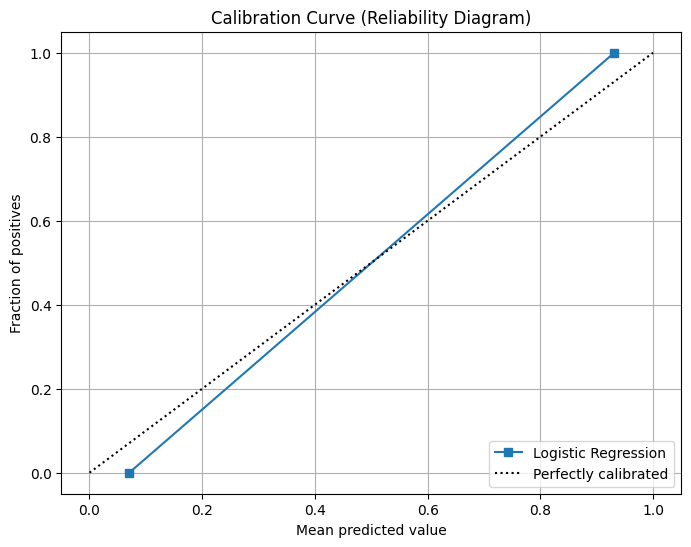

Brier Score: 0.0049


In [ ]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'pipe' is your trained scikit-learn pipeline (TF-IDF + Logistic Regression)
# and X_te, y_te are your test data from the earlier classification example.

# Get predicted probabilities for the positive class (class 1)
y_prob = pipe.predict_proba(X_te)[:, 1]

# Calculate calibration curve data
# fraction_of_positives: The proportion of positive instances in each bin
# mean_predicted_value: The mean predicted probability in each bin
fraction_of_positives, mean_predicted_value = calibration_curve(y_te, y_prob, n_bins=10)

# Plot the calibration curve (Reliability Diagram)
plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="Logistic Regression")
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated") # Plot the perfectly calibrated line
plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve (Reliability Diagram)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Calculate the Brier Score (measures the accuracy of probability predictions)
# A lower Brier score indicates better calibration.
brier_loss = brier_score_loss(y_te, y_prob)
print(f"Brier Score: {brier_loss:.4f}")

### Improving Calibration (Optional)

If your model is poorly calibrated, you can use techniques like Platt Scaling or Isotonic Regression to calibrate its predicted probabilities. `CalibratedClassifierCV` in scikit-learn provides an easy way to do this.

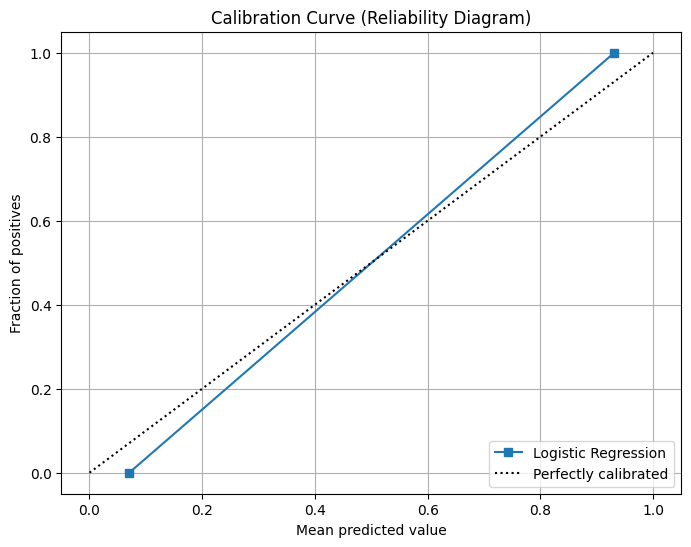

Brier Score: 0.0049


In [ ]:
# Get predicted probabilities for the positive class (class 1) from the fitted pipeline
y_prob = pipe.predict_proba(X_te)[:, 1]

# Calculate calibration curve data
fraction_of_positives, mean_predicted_value = calibration_curve(y_te, y_prob, n_bins=10)

# Plot the calibration curve (Reliability Diagram)
plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="Logistic Regression")
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated") # Plot the perfectly calibrated line
plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve (Reliability Diagram)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Calculate the Brier Score (measures the accuracy of probability predictions)
# A lower Brier score indicates better calibration.
brier_loss = brier_score_loss(y_te, y_prob)
print(f"Brier Score: {brier_loss:.4f}")